# P5: Engineer features

This protocol engineers the CPP feature space: parts, splits, and numerical channels (embeddings or structure). Feature engineering is the stage between raw sequences and a CPP **signature**. Before Comparative Physicochemical Profiling (CPP) can contrast a **test group** (`label=1`) against a **reference group** (`label=0`) and read out *what physicochemically distinguishes them*, every protein has to be turned into a structured feature space. AAanalysis builds that space from one small grammar: a feature is always a `Part-Split-Scale` triple, a named region (**part**), a rule for *which* positions to average (**split**), and a value axis. Here we engineer that space at the **domain level** (dataset prefix `DOM_`), where the **unit of comparison** is the TMD-centric **part** set.

> **Key mental model.** A feature = **part × split × scale**: *where* in the sequence (`tmd`, `jmd_n_tmd_n`, `tmd_c_jmd_c`), *how* the positions are picked (`Segment` / `Pattern` / `PeriodicPattern`), and *what value* is averaged. The value axis has two interchangeable sources: a physicochemical **scale** (the *sequence arm*, `CPP.run`) or a per-residue numerical tensor, a protein-language-model (PLM) embedding or a structure channel (the *numerical arm*, `CPP.run_num`). Same grammar, same `df_feat` output; only the value source changes. That is exactly what lets learned and structural representations ride the same interpretable CPP machinery.

**When to use it.** Reach for this protocol once you have **labelled sequences** (a `df_seq` with a binary `label`) and need to turn them into a CPP-ready feature space, the step that sits underneath every CPP run, whether the downstream task is **determinant discovery** or **prediction**. It answers the three engineering questions hiding under that grammar:

- **Where?** Slice each protein into TMD-centric **parts**. By default `get_df_parts` returns the base part `tmd` plus the composites `jmd_n_tmd_n` and `tmd_c_jmd_c` (built from the base parts `jmd_n` / `tmd` / `jmd_c`).
- **Which positions?** Pick a **split** type: `Segment` (a contiguous block), `Pattern`, or `PeriodicPattern` (spaced positions).
- **What value?** Average a physicochemical **scale** (the *sequence arm*, consumed by `CPP.run`) or a per-residue numerical vector such as a PLM embedding or a structural channel (the *numerical arm*, consumed by `CPP.run_num`).

Both arms share the identical Part-Split grammar and emit the identical `df_feat` schema, so anything you learn on the sequence arm transfers directly to embeddings and structure.

**When *not* to use it.** Skip the manual enumeration if you just want a signature with sensible defaults: `CPP.run` builds parts and splits internally, so you only need this protocol when you want to *control* the feature space or feed in numerical channels. It is also not where you decide the **compositional vs positional** trade-off (that is *P6: Compositional vs positional*), and for **residue-level** tasks you first manufacture fixed-length windows (parts named by the Schechter-Berger convention) in *Protocol 3 - Construct sets & sampling* before engineering features.

**Input.** A `df_seq` with one row per protein: an `entry` identifier, a `sequence`, and a binary `label` (**test group** = 1 vs. **reference group** = 0). For a **domain-level** task it also carries `tmd_start` / `tmd_stop`, from which the **part** boundaries are derived. Upstream this `df_seq` typically arrives from *Protocol 3 - Construct sets & sampling* (residue level) or from a curated labelled set (domain level, as here).

The **numerical arm** adds one more input: a `dict_num` mapping each `entry` to a per-residue tensor of shape `(L, D)`, where `L` equals the sequence length and `D` is the number of numerical channels (embedding or structure dimensions). Real PLM embeddings (ProtT5, ESM) are heavy to compute, so you generate them **separately on a GPU** (e.g. the companion Colab notebook), then save the `(L, D)` tensors and load them here; AAanalysis never runs the model itself. To keep this protocol offline and fast we instead build a **small synthetic** `dict_num` with NumPy. The real workflow would substitute a ProtT5 / ESM embedding or a DSSP / structure tensor of the same `(L, D)` shape. We use the bundled `DOM_GSEC` gamma-secretase dataset (substrates vs. non-substrates) throughout.

In [1]:
import aaanalysis as aa
import numpy as np

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Domain-level gamma-secretase data: substrates (label=1) vs non-substrates (0).
# load_dataset(name=..., n=10) returns 2*n = 20 rows (10 per class).
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = df_seq["label"].to_list()          # use the label column, NOT len(df_seq)
aa.display_df(df=df_seq, n_rows=5)

,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Run: Arm A, sequence features (scale-based).** The sequence arm turns `df_seq` into a CPP-ready feature space in three small steps: slice the parts, configure *how* to split, then enumerate the full grammar (see the SequenceFeature tutorial, `tutorial3b_sequence_feature`, for the function details):

1. `SequenceFeature.get_df_parts` slices each protein into the TMD-centric **parts** (by default the base part `tmd` plus the composites `jmd_n_tmd_n` and `tmd_c_jmd_c`), producing the `df_parts` that `CPP` consumes.
2. `SequenceFeature.get_split_kws` builds the **split** configuration, one entry per split type (`Segment`, `Pattern`, `PeriodicPattern`).
3. `SequenceFeature.get_features` enumerates the full `Part-Split-Scale` space as a list of feature ids.

In [2]:
sf = aa.SequenceFeature()

# 1) Parts: slice sequences into TMD-centric parts
df_parts = sf.get_df_parts(df_seq=df_seq)

# 2) Split configuration: Segment / Pattern / PeriodicPattern
split_kws = sf.get_split_kws()

# Split types in the configuration: ['Segment', 'Pattern', 'PeriodicPattern']
list(split_kws)

['Segment', 'Pattern', 'PeriodicPattern']

In [3]:
# 3) Enumerate the PART-SPLIT-SCALE space. The full scale set explodes
#    combinatorially, so restrict to a 3-scale slice for the demo.
df_scales = aa.load_scales()
small_scales = list(df_scales.columns[:3])

features = sf.get_features(split_kws=split_kws, list_scales=small_scales)
# Number enumerated (3 parts x splits x 3 scales): len(features)
len(features), features[:5]

(2970,
 ['TMD-Segment(1,1)-ANDN920101',
  'TMD-Segment(1,1)-ARGP820101',
  'TMD-Segment(1,1)-ARGP820102',
  'TMD-Segment(1,2)-ANDN920101',
  'TMD-Segment(1,2)-ARGP820101'])

In [4]:
# Optional: reduce redundancy. Build the feature matrix, then drop columns
# that correlate above max_cor with an already-kept feature.
# Note: filter_correlation keeps the FIRST-SEEN representative of each
# correlated group. Applied pre-CPP on the raw PART-SPLIT-SCALE enumeration
# order, it yields a redundancy-reduced but importance-agnostic set. To keep
# the most important representative, apply it to an importance-ordered
# CPP.run / df_feat output instead (see Protocol 1 - CPP signature).
X = sf.feature_matrix(features=features, df_parts=df_parts, n_jobs=1)
is_selected = aa.NumericalFeature.filter_correlation(X, max_cor=0.7)

# Features kept after redundancy filtering:
int(is_selected.sum())

368

**Run: Arm B, numerical features (embeddings / structure).** The numerical arm replaces the per-AA scale lookup with a **per-residue tensor**. The Part-Split grammar is unchanged; only the value source differs.

> **The Arm B tensor below is synthetic NumPy noise, so every `abs_auc` / `mean_dif` it produces is pure chance: treat it as a plumbing demo, not a signature.** Swap in a real ProtT5 / ESM embedding or a DSSP / structure tensor of the same `(L, D)` shape for a meaningful readout.

1. Build a `dict_num` of `{entry: (L, D) ndarray}`. We synthesise one with `np.random.default_rng(42)`; `rng.random` already yields values in `[0, 1)`, which is exactly the range `CPP.run_num` expects (its `max_std_test` pre-filter is calibrated for `[0, 1]`), so no normalisation step is needed. With *real* PLM embeddings the values are unbounded, so you would first run them through `EmbeddingPreprocessor.encode` (`ep.encode(df_seq=df_seq, embeddings=...)`, the sanctioned step from raw embeddings to `dict_num` that fits one `[0, 1]` normaliser per channel) before `get_parts`.
2. **`EmbeddingPreprocessor.build_scales` / `build_cat`** name the `D` dimensions (`df_scales` of shape `(20, D)`, `df_cat` of shape `(D, ...)`) so the `CPP` invariant `D == len(df_scales.columns) == len(df_cat)` holds. The per-AA scale values are *not* the per-residue value source for `run_num` (that is `dict_num_parts`), but the `df_cat` categories, derived from these pseudo-scales by clustering, **do** drive category-aware redundancy filtering and grouping. Deriving `df_scales`/`df_cat` from the *same* `dict_num` (rather than fabricating an arbitrary `(20, D)` / `df_cat`) is therefore what keeps both the invariant and the categories meaningful.
3. **`NumericalFeature.get_parts`** slices the sequence strings AND the tensor with the *same* boundaries, returning `(df_parts, dict_num_parts)`.
4. **`CPP.run_num`** runs the identical CPP algorithm on the sliced tensor.

In [5]:
D = 4                                   # tiny embedding dimensionality
rng = np.random.default_rng(42)

# Per-residue tensor: one (L, D) array per entry, L == sequence length, in [0, 1)
dict_num = {e: rng.random((len(s), D))
            for e, s in zip(df_seq["entry"], df_seq["sequence"])}

# Name the D dimensions. dict_num_parts (not these per-AA values) is the
# per-residue value source for run_num; but df_cat's categories - derived
# from these pseudo-scales - drive category-aware redundancy filtering, so we
# derive both from the same dict_num rather than fabricating them.
# Shapes: df_scales_num is (20, D); df_cat_num is (D, ...).
ep = aa.EmbeddingPreprocessor()
df_scales_num = ep.build_scales(df_seq=df_seq, dict_num=dict_num)
df_cat_num = ep.build_cat(df_scales=df_scales_num, random_state=42)
aa.display_df(df=df_scales_num, n_rows=5)

/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_43985/3470844455.py:14: UserWarning: Pseudo-scales are dataset-dependent (averaged over df_seq). For reproducible cross-dataset comparison, compute them once on a fixed reference corpus and reuse the resulting df_scales.
  df_scales_num = ep.build_scales(df_seq=df_seq, dict_num=dict_num)


,dim_0,dim_1,dim_2,dim_3
A,0.492584,0.497712,0.485069,0.513540
C,0.502098,0.506278,0.518440,0.502096
D,0.487394,0.508945,0.499097,0.498795
E,0.482504,0.494474,0.511045,0.497436
F,0.508067,0.473032,0.475938,0.501151


In [6]:
# Slice sequences AND tensor with shared part boundaries
df_parts_num, dict_num_parts = aa.NumericalFeature.get_parts(df_seq=df_seq, dict_num=dict_num)

# Each part tensor has shape (n_samples, L_part_max, D), NaN-padded
{k: v.shape for k, v in dict_num_parts.items()}

{'tmd': (20, 23, 4), 'jmd_n_tmd_n': (20, 22, 4), 'tmd_c_jmd_c': (20, 21, 4)}

In [7]:
# Numerical-mode CPP: same algorithm and df_feat schema as CPP.run
cpp = aa.CPP(df_parts=df_parts_num,
             df_scales=df_scales_num,
             df_cat=df_cat_num,
             verbose=False)
df_feat = cpp.run_num(dict_num_parts=dict_num_parts,
                      labels=labels,
                      n_filter=10,
                      n_jobs=1)        # serial: avoids spawn footgun on Py3.14 + macOS
aa.display_df(df=df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc"]], n_rows=5)

,feature,category,subcategory,mean_dif,abs_auc
1,"TMD_C_JMD_C-Pat...C,4,7,10)-dim_1",Embeddings,Embeddings_cat1_subcat0,-0.216000,0.360000
2,"TMD_C_JMD_C-Pat...,9,12,15)-dim_1",Embeddings,Embeddings_cat1_subcat0,-0.174000,0.360000
3,"JMD_N_TMD_N-Pat...,6,10,14)-dim_0",Embeddings,Embeddings_cat0_subcat1,0.174000,0.360000
4,"JMD_N_TMD_N-Pat...,8,11,14)-dim_3",Embeddings,Embeddings_cat0_subcat2,0.165000,0.350000
5,"TMD-Pattern(N,2,5,8)-dim_3",Embeddings,Embeddings_cat0_subcat2,0.152000,0.340000


In [8]:
# Multiple per-residue sources combine along the D axis before get_parts.
# Here a second synthetic channel stands in for a structural tensor.
dict_struct = {e: rng.random((len(s), 2)) for e, s in zip(df_seq["entry"], df_seq["sequence"])}
dict_combined = aa.combine_dict_nums([dict_num, dict_struct])
{e: dict_combined[e].shape for e in list(dict_combined)[:3]}   # D = 4 + 2 = 6

{'Q14802': (87, 6), 'Q86UE4': (582, 6), 'Q969W9': (287, 6)}

**Output.** **Arm A (sequence)** produces three objects:
- `df_parts`: one row per protein, one column per **part** (`tmd`, `jmd_n_tmd_n`, `tmd_c_jmd_c`); the primary input to `CPP`.
- `split_kws`: the **split** configuration dict.
- `features`: a list of `Part-Split-Scale` feature ids, optionally reduced by `filter_correlation`.

**Arm B (numerical)** produces:
- `(df_parts_num, dict_num_parts)` from `get_parts`; each `dict_num_parts[part]` is a NaN-padded array of shape `(n_samples, L_part_max, D)`, aligned row-for-row with `df_parts_num`.
- `df_feat`: the **signature**, with the **same schema** as `CPP.run` (`feature`, `category`, `subcategory`, `mean_dif`, `abs_auc`, ...). The value axis is now the embedding channels (`dim_0` ... `dim_3`) instead of physicochemical scales.

The bar plot below makes the engineered Arm A space concrete: it tallies the `features` enumeration by **part** (x-axis) and **split** type (colour). Notice how every part carries the same `Segment` / `Pattern` / `PeriodicPattern` stack: the grammar is uniform across parts, and what multiplies the count is simply how many scales (sequence arm) or numerical channels (numerical arm) you enumerate over.

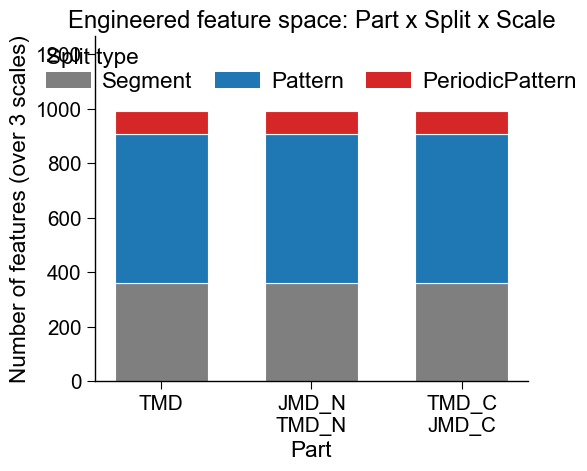

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tally the Arm A enumeration: every feature id is a Part-Split-Scale triple,
# so we count features by part (x-axis) and split type (stacked colour).
parts_order = ["TMD", "JMD_N_TMD_N", "TMD_C_JMD_C"]
part_labels = ["TMD", "JMD_N\nTMD_N", "TMD_C\nJMD_C"]
split_types = list(split_kws)                 # ['Segment', 'Pattern', 'PeriodicPattern']
counts = {st: [0] * len(parts_order) for st in split_types}
for feat in features:
    tokens = feat.split("-")
    part, split = tokens[0], tokens[1]
    st = split.split("(")[0]
    if part in parts_order and st in counts:
        counts[st][parts_order.index(part)] += 1

# Publication styling (plotting_prelude): clean stacked bar with despine + tidy legend.
aa.plot_settings(font_scale=0.9, weight_bold=False)
colors = aa.plot_get_clist(n_colors=len(split_types))

fig, ax = plt.subplots(figsize=(6, 5))
x = range(len(parts_order))
bottom = [0] * len(parts_order)
dict_color = {}
for st, color in zip(split_types, colors):
    ax.bar(x, counts[st], bottom=bottom, label=st, color=color,
           width=0.62, edgecolor="white", linewidth=0.8)
    bottom = [b + c for b, c in zip(bottom, counts[st])]
    dict_color[st] = color

total = max(bottom)
ax.set_xticks(list(x))
ax.set_xticklabels(part_labels)
ax.set_ylim(0, total * 1.28)
ax.set_xlabel("Part")
ax.set_ylabel("Number of features (over 3 scales)")
ax.set_title("Engineered feature space: Part x Split x Scale",
             size=aa.plot_gcfs() + 1)
sns.despine()

# Clean horizontal legend in the headroom above the bars (no occlusion).
aa.plot_legend(ax=ax, dict_color=dict_color, title="Split type",
               loc="upper center", x=0.5, y=1.0, n_cols=3,
               columnspacing=1.0, handletextpad=0.5)

plt.tight_layout()
plt.show()

**How to interpret.**

| Output | Reading |
| --- | --- |
| a `df_parts` row | the default parts (the base part `tmd` plus the composites `jmd_n_tmd_n` and `tmd_c_jmd_c`, derived from the base parts `jmd_n` / `tmd` / `jmd_c`) of one protein |
| a `split_kws` entry | the rule for *which positions* are averaged (`Segment` = contiguous block, `Pattern` / `PeriodicPattern` = spaced positions) |
| a `Part-Split-Scale` id (Arm A) | *where* + *how* + *which physicochemical property* |
| a `Part-Split-dimension` id (Arm B) | *where* + *how* + *which embedding / structure channel* (`dim_0` ...) |
| `mean_dif` sign | direction of separation (positive = higher in the **test group** in that region) |
| `abs_auc` | effect size / separation strength of the feature |

Both arms read the same way: a coherent block of high-`abs_auc` features from one property family or embedding channel, localized to one part, is the **signature** that distinguishes substrates from non-substrates. The numerical arm simply lets you profile learned / structural representations with the same interpretable grammar. One caveat for this demo: because the Arm B tensor is synthetic NumPy noise, the `abs_auc` / `mean_dif` values shown above are **not** biologically meaningful (the small effect sizes are pure chance). Swap in a real ProtT5 / ESM embedding or a DSSP / structure tensor of the same `(L, D)` shape and the identical readout surfaces the channels that actually separate the **test group** from the **reference group**.

**Key takeaways**
- A feature is always **part × split × scale**: control *where*, *how*, and *what value* independently, and the engineered space follows mechanically.
- The **sequence arm** (`CPP.run`, physicochemical scales) and the **numerical arm** (`CPP.run_num`, per-residue tensors via `dict_num`) share one grammar and one `df_feat` schema, so embeddings and structure ride the same interpretable machinery.
- The shape of the space is yours to set: enumerate broadly to explore, then reduce redundancy with `filter_correlation` before committing to a CPP run.

**Common mistakes.**

- **Passing `df_seq` into `CPP`**: `CPP` takes `df_parts`; build them with `get_df_parts` (Arm A) or `get_parts` (Arm B) first.
- **Feeding raw, unbounded embeddings into `run_num`**: values must be in `[0, 1]` (the `max_std_test` pre-filter is calibrated for that range); pass real PLM embeddings through `EmbeddingPreprocessor.encode` first. Our synthetic tensor is already in range, so it skips that step.
- **`dict_num` length mismatch**: each `dict_num[entry]` must have `L == len(sequence)`; otherwise `get_parts` cannot align the tensor to the parts.
- **`D` mismatch**: `D` must equal `len(df_scales.columns)` and `len(df_cat)`; deriving both with `build_scales`/`build_cat` from the same `dict_num` keeps the invariant.
- **Using `len(df_seq)` for class sizes**: use the `label` column; `load_dataset(..., n=N)` returns `2N` rows.
- **Relying on the default `n_jobs`**: on Python 3.14 + macOS, multiprocessing spawn without a `__main__` guard is fragile; pass `n_jobs=1` in notebooks.
- **Enumerating the full scale set**: `get_features` over hundreds of scales explodes combinatorially; slice `list_scales` for exploration.

**Next step.**

- **Compositional vs positional** leads to *P6: Compositional vs positional*. You now know a feature is `Part-Split-Scale`; P6 shows how the **split** alone decides whether a feature is composition-like (whole-part `Segment(1,1)`, position-agnostic) or position-resolved (`Segment` with `n_split_max > 1`, `Pattern`, `PeriodicPattern`), and how that choice maps onto the **prediction level**.
- **Run the signature** by feeding the engineered `df_parts` straight into the CPP signature: see *Protocol 1 - CPP signature*.